In [1]:
import os
import timm
import torch
import numpy as np

import utils.data as data_utils
from utils.predict import PredictPlants

random_seed = 8

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared
Found 9 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Ranunculus aquatilis']
Remapped 19 images to use canonical indices.
Total dataset size 	: 19
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 19

Test DataLoader created with 19 images from /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared.
Classnames 


## Model

In [2]:
timm_model_name = "convnextv2_tiny.fcmae_ft_in22k_in1k"

best_model_path = "/home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth"
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model file not found: {best_model_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    torch.cuda.manual_seed(random_seed)
    print("GPU: ", torch.cuda.get_device_name(0))
    
model = timm.create_model(timm_model_name, pretrained=False, num_classes=21)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded from {best_model_path}")

Using device: cuda
GPU:  NVIDIA RTX A500 Laptop GPU
Model loaded from /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


## Predictor

In [3]:
predictor = PredictPlants(timm_model_name, best_model_path, 21)

In [5]:
eval = predictor.evaluate_with_predict_fn()

100%|██████████| 19/19 [00:05<00:00,  3.18it/s]

Accuracy: 0.4211
Overall Accuracy: 0.4211


In [7]:
info = eval.get_classwise_metrics()


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |   F1-Score |   Specificity (TNR) |       FPR |
+==========================+===========+======+======+======+=============+================+============+=====================+===========+
| Brasenia schreberi       |         0 |    0 |    0 |    0 |         0   |       0        |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Cabomba                  |         0 |    0 |    0 |    0 |         0   |       0        |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+


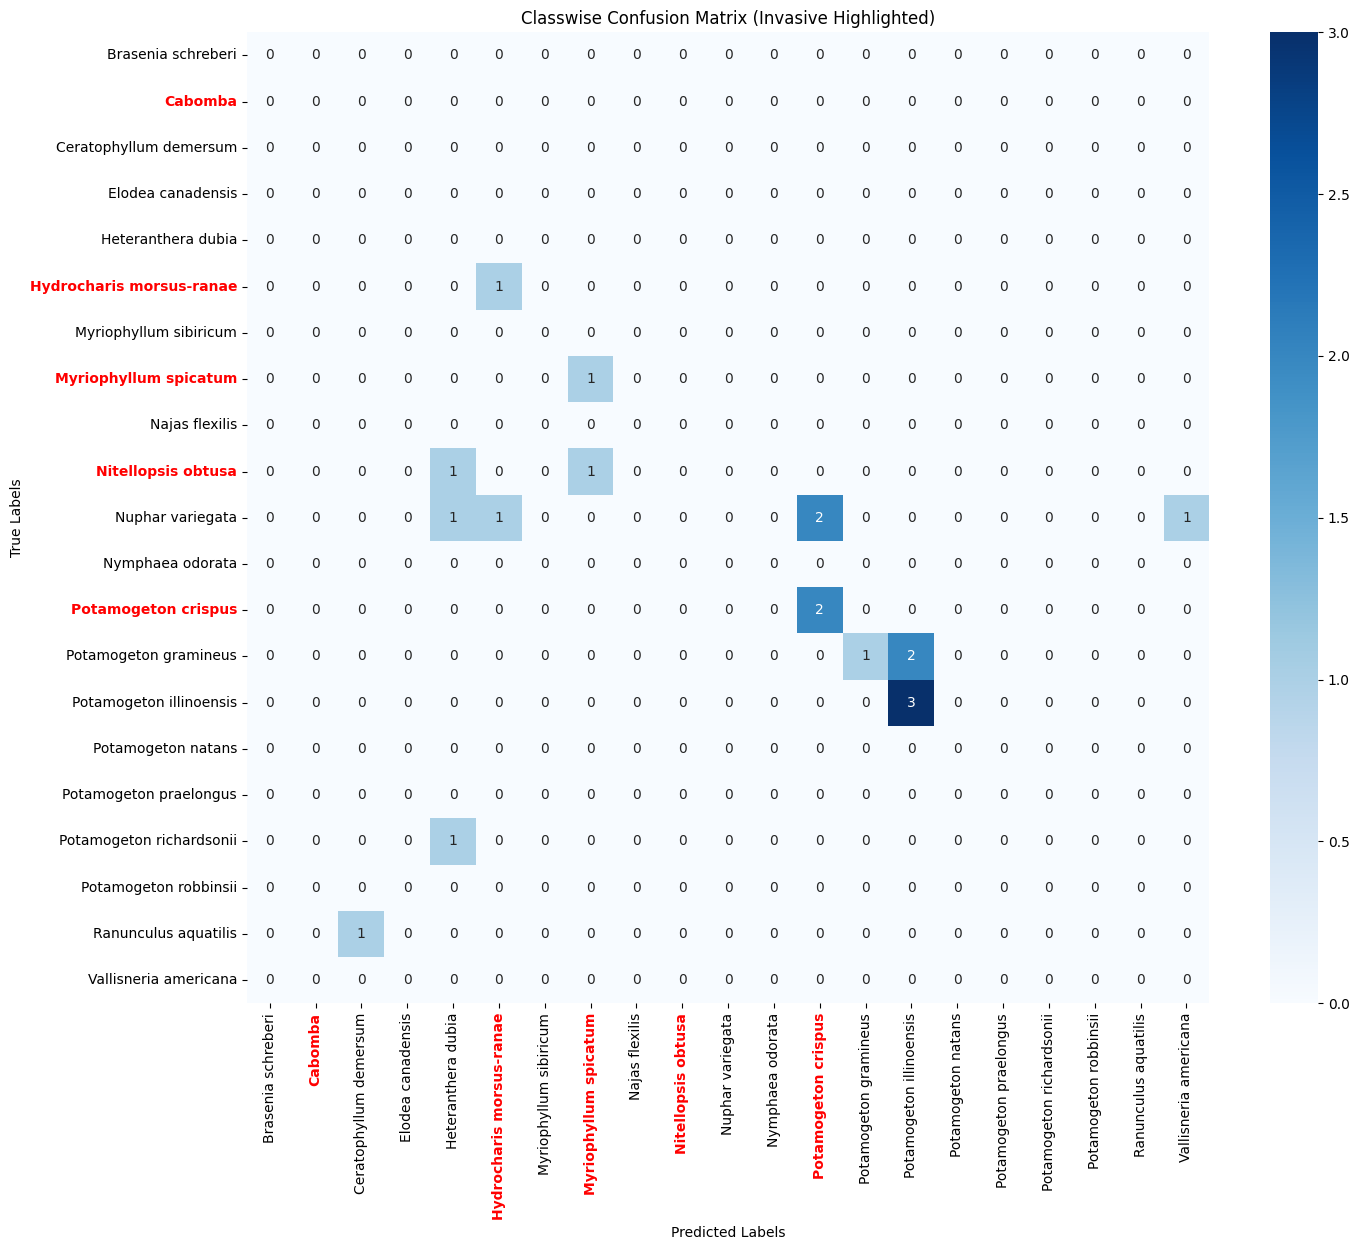

In [8]:
cm = eval.get_classwise_confusion_matrix()

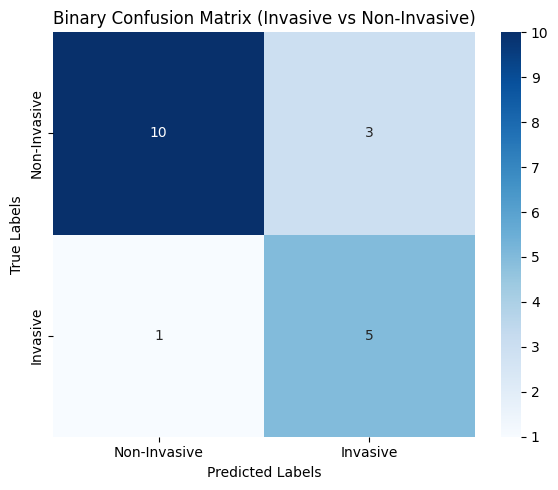


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        5 | False Positive Rate (FPR)      |    0.2308 | Negative Predictive Value (NPV) |    0.9091 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |       10 | False Negative Rate (FNR)      |    0.1667 | Positive " (PPV or Precision)   |    0.625  |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        3

In [11]:

bimcm = eval.get_binary_confusion_matrix()
bin = eval.get_binary_metrics()